# DecisionTreeClassifier Model
<div dir='rtl'>
    <p>فى الامثله السابقه كنا نستخدم <code>LogisticRegrission</code> للـ <code>classification</code> ولكن هذا الـ <code>model</code> يشبه الصندوق الاسود، لا يخبرنا كيف يفكر</p>
    <p>اليوم سوف نستخدم <code>model</code> يسمى <code>DecisionTreeClassifier</code> للتصنيف، هذا الموديل يعتمد على <code>if-statement</code> لأتخاذ القرار</p>
</div>

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [83]:
df = pd.read_csv(
    "Telco-Customer-Churn.csv",
    true_values=["Yes"],
    false_values=["No"],
    dtype={
        "SeniorCitizen": np.bool_,
        "tenure": np.int8,
        "MonthlyCharges": np.float32
    }
)
df.drop(columns=["customerID"], inplace=True)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,False,True,False,1,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,29.850000,29.85,False
1,Male,False,False,False,34,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,56.950001,1889.5,False
2,Male,False,False,False,2,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,53.849998,108.15,True
3,Male,False,False,False,45,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,Female,False,False,False,2,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,70.699997,151.65,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,False,True,True,24,True,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,True,Mailed check,84.800003,1990.5,False
7039,Female,False,True,True,72,True,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,True,Credit card (automatic),103.199997,7362.9,False
7040,Female,False,True,True,11,False,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,True,Electronic check,29.600000,346.45,False
7041,Male,True,True,False,4,True,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Mailed check,74.400002,306.6,True


## Data Cleaning
<p dir='rtl'>يشغل مره واحده فقط!!</p>

In [84]:
df['TotalCharges'] = np.where(df['TotalCharges'] == " ", 0, df["TotalCharges"]).astype(np.float32)
df = pd.get_dummies(df, columns=["gender", "MultipleLines", "InternetService", "OnlineSecurity" ,"OnlineBackup" ,"DeviceProtection" ,"TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"])

## Prepare the data

In [85]:
X = df.drop(columns=["Churn"])
Y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

## Train the model
<p dir='rtl'>
الـ <code>max_depth</code> يعنى اقصى حد للأسئله (<code>الفروع</code> او <code>if-statement</code>)
</p>

In [86]:
tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [87]:
round(tree_model.score(x_test, y_test) * 100, 2)

79.56

## plot the tree

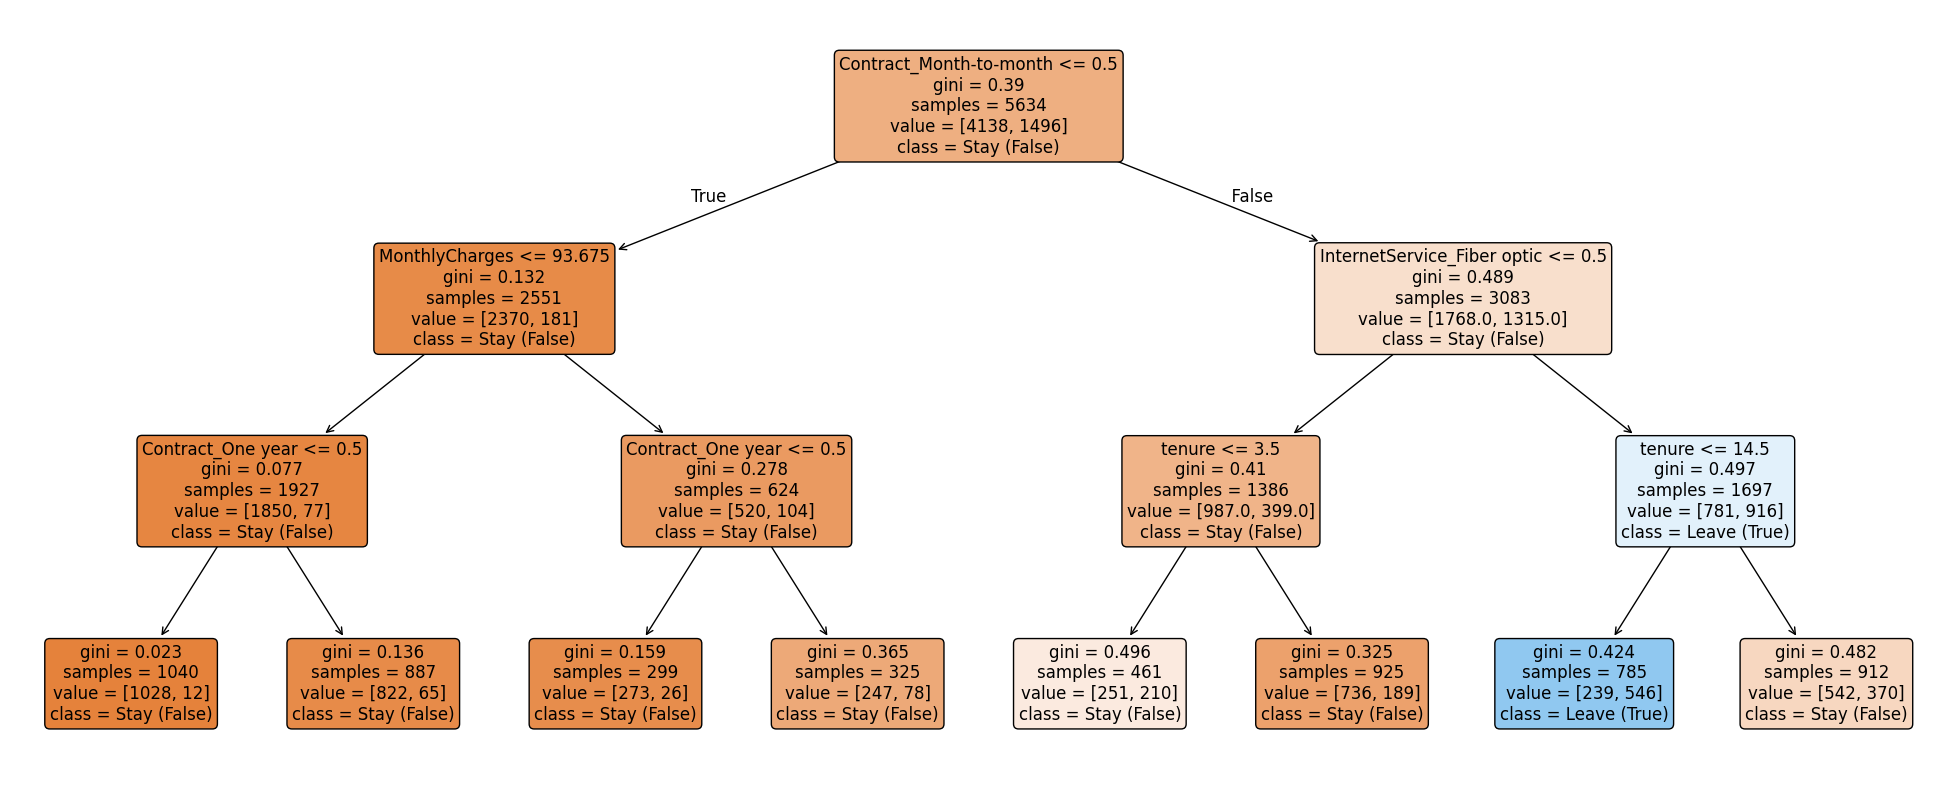

In [ ]:
plt.figure(figsize=(25,10))
plot_tree(
    tree_model, 
    feature_names=X.columns,
    class_names=["Stay (False)", "Leave (True)"],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()

## testing the model

In [89]:
prediction = tree_model.predict(x_test)
dt = pd.DataFrame(
    {
        "Churn": y_test.values,
        "Prediction": prediction
    }
)
print(f"Correct: {dt[dt['Churn'] == dt['Prediction']].shape[0]} ✅")
print(f"Wrone: {dt[dt['Churn'] != dt['Prediction']].shape[0]} ❌")

Correct: 1121 ✅
Wrone: 288 ❌


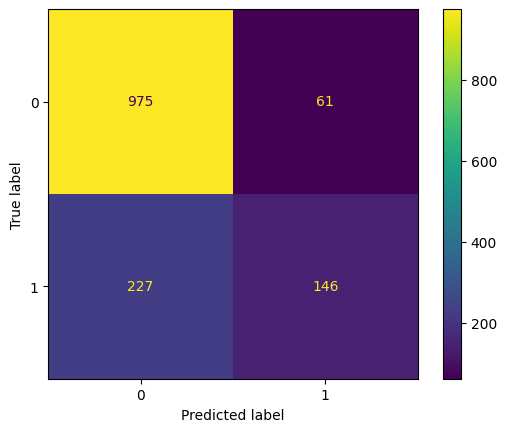

In [90]:
cm = confusion_matrix(y_test, prediction)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# RandomForestClassifier model
<div dir='rtl'>
    <p>شجره واحده غير كافيه؟</p>
    <p>إذاً نستخدم <code>model</code> يسمى <code>RandomForestClassifier</code> وهو يقوم بعمل اكثر من شجره (<code>غابه</code>) لأتخاذ القرار ويقوم بعمل تصويت (<code>vote</code>) لأتخاذ القرار</p>
    <ul>
        <li><b>n_estimators</b>: هو كم عدد الاشجار التى تريد إنشاءها؟</li>
        <li><b>max_depth</b>: كم فرع لكل شجره تريد؟</li>
    </ul>
    <p>للأسف لا يمكننا عرض الاشجار جميعاً فى وقت واحد ولكن يمكن عرض شجره واحده</p>
</p>

In [91]:
from sklearn.ensemble import RandomForestClassifier

In [92]:
forest_model = RandomForestClassifier(n_estimators=150, max_depth=8)
forest_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [93]:
round(forest_model.score(x_test, y_test) * 100, 2)

80.55

In [94]:
forest_prediction = forest_model.predict(x_test)
forest_dt = pd.DataFrame(
    {
        "Churn": y_test.values,
        "Prediction": forest_prediction
    }
)
print(f"Correct: {forest_dt[forest_dt['Churn'] == forest_dt['Prediction']].shape[0]} ✅")
print(f"Wrone: {forest_dt[forest_dt['Churn'] != forest_dt['Prediction']].shape[0]} ❌")

Correct: 1135 ✅
Wrone: 274 ❌


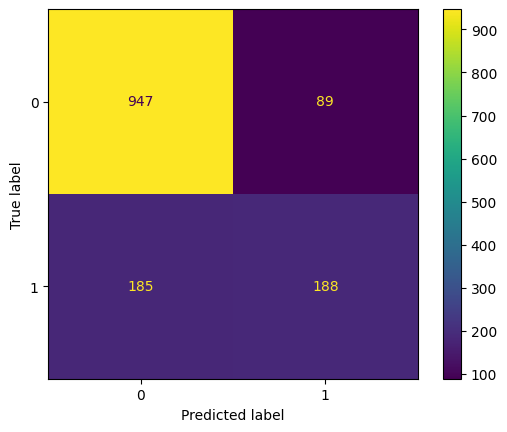

In [95]:
cm = confusion_matrix(y_test, forest_prediction)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# Testing All models

In [96]:
from sklearn.linear_model import LogisticRegression

In [97]:
logistic_model = LogisticRegression(max_iter=3000)
logistic_model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [99]:
print(f"LogisticRegression score: {round(logistic_model.score(x_test, y_test) * 100, 2)}%")
print(f"DecisionTreeClassifier score: {round(tree_model.score(x_test, y_test) * 100, 2)}%")
print(f"RandomForestClassifier score: {round(forest_model.score(x_test, y_test) * 100, 2)}%")

LogisticRegression score: 82.04%
DecisionTreeClassifier score: 79.56%
RandomForestClassifier score: 80.55%


<div dir='rtl'>
    <h1>الملخص</h1>
    <p>كما ترى الـ <code>LogisticRegression</code> هو الموديل المناسب لهذه البيانات</p>
    <hr />
    <h4>طرق تفكير الـ <code>models</code> المستخدمه فى هذا الدرس:</h4>
    <ul>
        <p><b>LogisticRegression</b>: يقوم بمراجعة البيانات كحد اقصى 3000 مره</p>
        <p><b>DecisionTreeClassifier</b>: يقوم بعمل شجرة اتخاذ القرار يستخدم <code>if-statement</code></p>
        <p><b>RandomForestClassifier</b>: يقوم بعمل غابه بها اكثر من شجره ويستخدم التصويت لأتخاذ القرار</p>
    </ul>
</div>